In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import struct

import matplotlib.pyplot as plt

from spikeinterface.core import NumpySorting
import spikeinterface.extractors as se
from spikeinterface import create_sorting_analyzer

In [ ]:
path_data = Path("/media/Neuralynx/####")

df_channel_names = pd.read_csv(path_data / "ChannelNames.txt", header=None)
df_channel_names["ch_name"] = df_channel_names[0].str.removesuffix(".ncs")

In [36]:
# get the first timestamp from a raw ncs file to use to align the spike times
# necessary for later combing the sorting object with the analyzer
ncs_path = path_data / "CSC1.ncs" 

with open(ncs_path, "rb") as f:
    f.seek(16384)  
    first_record = f.read(1044)

timestamp_us = struct.unpack("<Q", first_record[:8])[0] 
print("First sample timestamp (µs since acquisition start):", timestamp_us)

sampling_frequency = 32768
offset_samples = round(timestamp_us * sampling_frequency / 1e6)
print(offset_samples)

First sample timestamp (µs since acquisition start): 68816394491
2254975615


In [ ]:
# quick file check

ch_nr = 1
path_file = path_data / f"CSC{ch_nr}"

for i in path_file.iterdir():
    print(i)

In [ ]:
recording = se.read_neuralynx("/media/Neuralynx/####")

In [40]:
# channel names are taken from the recording system schema and don't match the auto reindexing that combinato does
# create a lookup table here to skirt the issue

ch_lookup = pd.DataFrame({
    "obj_name": recording.channel_ids,
    "ch_location": recording._properties["channel_name"]
})

ch_lookup["csc_nr"] = [np.int32(df_channel_names[df_channel_names["ch_name"] == row.ch_location].index)[0] + 1 for i, row in ch_lookup.iterrows()]

In [ ]:
path_file = "/media/Neuralynx/XXXX/CSC1"

sorting = se.read_combinato(
    folder_path=path_file,
    sampling_frequency=32768, 
    user="tho",
    det_sign="pos",
    keep_good_only=False,
)

In [42]:
shifted_spike_trains = {
    unit_id: sorting.get_unit_spike_train(unit_id) - offset_samples
    for unit_id in sorting.unit_ids
}

sorting_shifted = NumpySorting.from_unit_dict(shifted_spike_trains, sampling_frequency=sorting.sampling_frequency)

In [44]:
sorting_shifted.count_num_spikes_per_unit()
# from combinato: 438       11638        6975        2360

{np.int64(0): np.int64(438),
 np.int64(1): np.int64(11638),
 np.int64(2): np.int64(6975),
 np.int64(3): np.int64(2360)}

In [45]:
ch_id = ch_lookup[ch_lookup["csc_nr"] == ch_nr]["obj_name"].iloc[0]
recording_csc1 = recording.select_channels([ch_id])

recording_csc1

ChannelSliceRecording: 1 channels - 32.8kHz - 1 segments - 45,840,896 samples 
                       1,398.95s (23.32 minutes) - int16 dtype - 87.43 MiB

In [48]:

recording_csc1.set_dummy_probe_from_locations(locations=np.array([[0, 0]]))

analyzer = create_sorting_analyzer(
    sorting=sorting_shifted,
    recording=recording_csc1,
    format="binary_folder",
    folder="analyzer_CSC1",
    sparse=False,
    overwrite=True
)

In [57]:
analyzer.compute("random_spikes")
analyzer.compute("waveforms")
analyzer.compute("templates")
analyzer.compute("quality_metrics")

compute_waveforms (no parallelization):   0%|          | 0/1399 [00:00<?, ?it/s]

compute_waveforms (no parallelization): 100%|██████████| 1399/1399 [00:01<00:00, 898.60it/s] 
/opt/miniconda3/envs/unitrefine/lib/python3.14/site-packages/spikeinterface/core/analyzer_extension_core.py:1165: UserWarning: The following metrics will not be computed due to missing dependencies: ['snr', 'amplitude_cutoff', 'drift', 'silhouette', 'noise_cutoff', 'nearest_neighbor', 'amplitude_cv', 'amplitude_median', 'd_prime', 'mahalanobis', 'sd_ratio']
  warnings.warn(
/opt/miniconda3/envs/unitrefine/lib/python3.14/site-packages/spikeinterface/core/analyzer_extension_core.py:1282: UserWarning: Error computing metric sliding_rp_violation: module 'numpy' has no attribute 'row_stack'
  warnings.warn(f"Error computing metric {metric_name}: {e}")


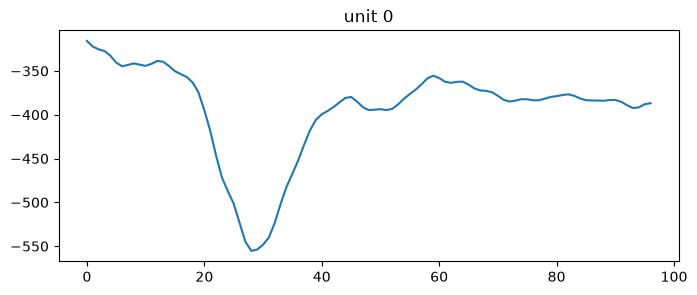

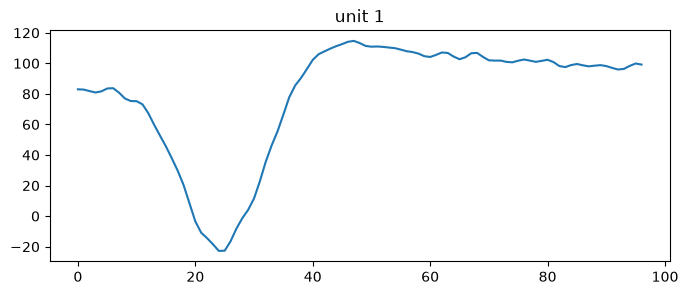

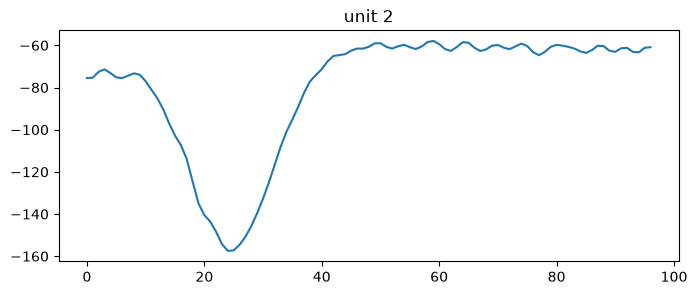

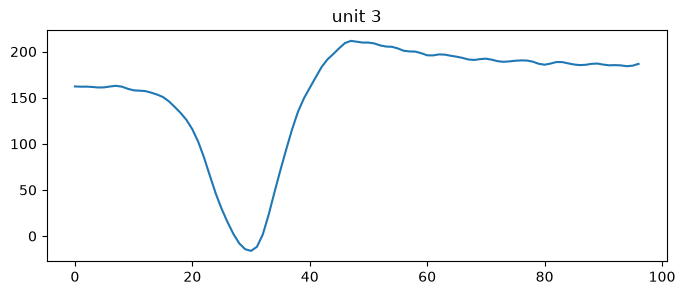

In [61]:
templates = analyzer.get_extension("templates").get_data()

for i, unit_id in enumerate(analyzer.unit_ids):
    plt.figure(figsize=(8, 3))
    plt.plot(templates[i, :, 0])
    plt.title(f"unit {unit_id}")
    plt.show()